## Environment setup

In [7]:
from datetime import datetime 
import uproot
import awkward as ak
import tensorflow as tf
import numpy as np
import importlib
from functools import partial
from termcolor import colored

from tensorflow.data import Dataset, TFRecordDataset
from tensorflow.data.experimental import TFRecordWriter
from tensorflow.train import BytesList, FloatList, Int64List
from tensorflow.train import Example, Features, Feature
import tensorflow_datasets as tfds
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Notebooks run from VSCode use home directory as a base path
# while notebooks run from JupyterLab use the current directory as a base path
import sys, os

user = os.getenv("USER")
if user == None:
    sys.path.append("/home/jovyan/TPCReco/PythonAnalysis/python/")
    os.chdir("/home/jovyan/TPCReco/PythonAnalysis/")
else:
    sys.path.append("/home/akalinow/scratch/ELITPC/TPCReco/PythonAnalysis/python/")
    os.chdir('/home/akalinow/scratch/ELITPC/PythonAnalysis/')

import io_functions as io
import utility_functions as utils
import plotting_functions as plf

os.makedirs("pics", exist_ok=True)
os.makedirs("dfs", exist_ok=True)

### Load the dataset and convert to pandas DataFrame

In [4]:
#MAKE SURE THIS PATH IS CORRECT
mergedOutputDir = './data/MergedEvent_Track3D_TwoProng_gun_MC_10k'

merged_dataset = tf.data.Dataset.load(
    mergedOutputDir,
    compression="GZIP"
)

nEvents = merged_dataset.reduce(
    tf.constant(0, dtype=tf.int64),
    lambda count, _: count + 1
).numpy()


val_fraction = 0.2
nVal = int(nEvents * val_fraction)
nTrain = nEvents - nVal

print("train events:", nTrain)
print("validation events:", nVal)

I0000 00:00:1788726998.993918      82 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 43475 MB memory:  -> device: 0, name: NVIDIA L40S, pci bus id: 0000:89:00.0, compute capability: 8.9
I0000 00:00:1788726998.994919      82 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 43475 MB memory:  -> device: 1, name: NVIDIA L40S, pci bus id: 0001:c5:00.0, compute capability: 8.9


train events: 7064
validation events: 1765


In [37]:
%%time
importlib.reload(utils)


#switching to relative coordinates
rows = []

for event in merged_dataset.take(nVal):

    y_sim_xyz = tf.reshape(
        event["sim"][1],
        (9,)
    )

    _, y_sim_rel = utils.xyz_to_relative_targets(
        tf.zeros(io.projections.shape, dtype=tf.float32),
        y_sim_xyz
    )

    y_reco_xyz = tf.reshape(
        event["reco"][1],
        (9,)
    )

    _, y_reco_rel = utils.xyz_to_relative_targets(
        tf.zeros(io.projections.shape, dtype=tf.float32),
        y_reco_xyz
    )

    row = np.concatenate(
        [
            y_sim_rel.numpy(),
            y_reco_rel.numpy()
        ]
    )

    rows.append(row)

data = np.vstack(rows)

df = pd.DataFrame(
    data=data,
    columns=utils.getSimRecoColumns(utils.columns_relative)
)

df.describe()

CPU times: user 17.7 s, sys: 167 ms, total: 17.8 s
Wall time: 12.2 s


2026-09-06 20:59:19.327470: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


,xVtx_sim,yVtx_sim,dxAlpha_sim,dyAlpha_sim,dzAlpha_sim,dxCarbon_sim,dyCarbon_sim,dzCarbon_sim,xVtx_reco,yVtx_reco,dxAlpha_reco,dyAlpha_reco,dzAlpha_reco,dxCarbon_reco,dyCarbon_reco,dzCarbon_reco
count,1765.000000,1765.000000,1765.000000,1765.000000,1765.000000,1765.000000,1765.000000,1765.000000,1765.000000,1765.000000,1765.000000,1765.000000,1765.000000,1765.000000,1765.000000,1765.000000
mean,-0.153984,-0.016493,-0.128506,-0.118381,-2.229922,-0.790092,0.003246,0.227025,-1.468296,-0.004684,0.489641,0.034741,-2.723909,-0.306860,-0.004235,0.352596
std,57.697029,1.003626,38.337860,32.149757,42.395214,5.817474,5.408108,6.456742,48.103127,1.463853,37.376194,31.360893,41.544724,6.166756,5.709219,6.937773
min,-99.975624,-3.348772,-178.119461,-89.003242,-113.052704,-15.256233,-12.115086,-16.428463,-99.809105,-17.644442,-178.650024,-88.501495,-114.880386,-17.108250,-13.751475,-20.499203
25%,-50.001438,-0.708311,-17.548775,-17.826340,-21.341311,-5.058029,-3.990054,-4.461334,-30.696672,-0.369432,-13.059817,-14.306910,-19.383120,-3.589241,-3.310315,-3.410759
50%,-3.567525,0.004993,0.001503,-0.062521,-0.494961,-0.729752,0.034563,0.136456,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,49.985836,0.659197,17.953131,17.627956,18.024643,3.373213,4.156997,5.128275,27.882351,0.361911,15.954617,14.854726,13.618862,2.836739,3.237070,4.706600
max,99.700493,3.269838,180.295135,89.637909,108.585297,14.288155,12.350929,16.125183,99.931625,18.735775,178.590881,92.498375,108.861908,26.366787,14.138866,20.129650


In [8]:
# df.to_csv("./dfs/df_class.csv", index=False)

In [38]:
df_check = df.copy()

df_check["dAlpha_reco_check"] = np.sqrt(
    df_check["dxAlpha_reco"]**2 +
    df_check["dyAlpha_reco"]**2 +
    df_check["dzAlpha_reco"]**2
)

df_check["dCarbon_reco_check"] = np.sqrt(
    df_check["dxCarbon_reco"]**2 +
    df_check["dyCarbon_reco"]**2 +
    df_check["dzCarbon_reco"]**2
)

In [46]:
eps = 1e-9

zero_alpha = df_check[df_check["dAlpha_reco_check"] < eps]
zero_carbon = df_check[df_check["dCarbon_reco_check"] < eps]

print("Number of zero predictions for the alpha particle:", len(zero_alpha))
print("Number of zero predictions for carbon:", len(zero_carbon))

Number of zero predictions for the alpha particle: 541
Number of zero predictions for carbon: 541


In [47]:
eps = 1e-9

nonzero_reco_mask = (
    (df_check["dAlpha_reco_check"] >= eps) &
    (df_check["dCarbon_reco_check"] >= eps)
)

df = df_check[nonzero_reco_mask].copy()

#removing all the zero predictions
print("Liczba zdarzeń przed filtrowaniem:", len(df_check))
print("Liczba zdarzeń po filtrowaniu:", len(df))
print("Usunięto zdarzeń:", len(df_check) - len(df))

Liczba zdarzeń przed filtrowaniem: 1765
Liczba zdarzeń po filtrowaniu: 1224
Usunięto zdarzeń: 541


In [41]:
df.to_csv("./dfs/df_class.csv", index=False)

In [48]:
#calculating track lengths

df["LAlpha_sim"] = np.sqrt(
    df["dxAlpha_sim"]**2 +
    df["dyAlpha_sim"]**2 +
    df["dzAlpha_sim"]**2
)

df["LCarbon_sim"] = np.sqrt(
    df["dxCarbon_sim"]**2 +
    df["dyCarbon_sim"]**2 +
    df["dzCarbon_sim"]**2
)

max_length_alpha = 150
max_length_carbon = 17
min_length_alpha = 0.0
max_length_alpha = 150.0


#fiducial cuts regarding the lengths of the tracks
mask = (
    (df["LCarbon_sim"] <= max_length_carbon) &
    (df["LAlpha_sim"] <= max_length_alpha)
)

df_cut = df[mask].copy()

print("Number of events before the cut", len(df))
print("After the cut:", len(df_cut))
print("Number of removed events:", len(df) - len(df_cut))

Number of events before the cut 1224
After the cut: 1190
Number of removed events: 34


Alpha track length efficiency: 0.9765 (97.65%) [1162/1190]


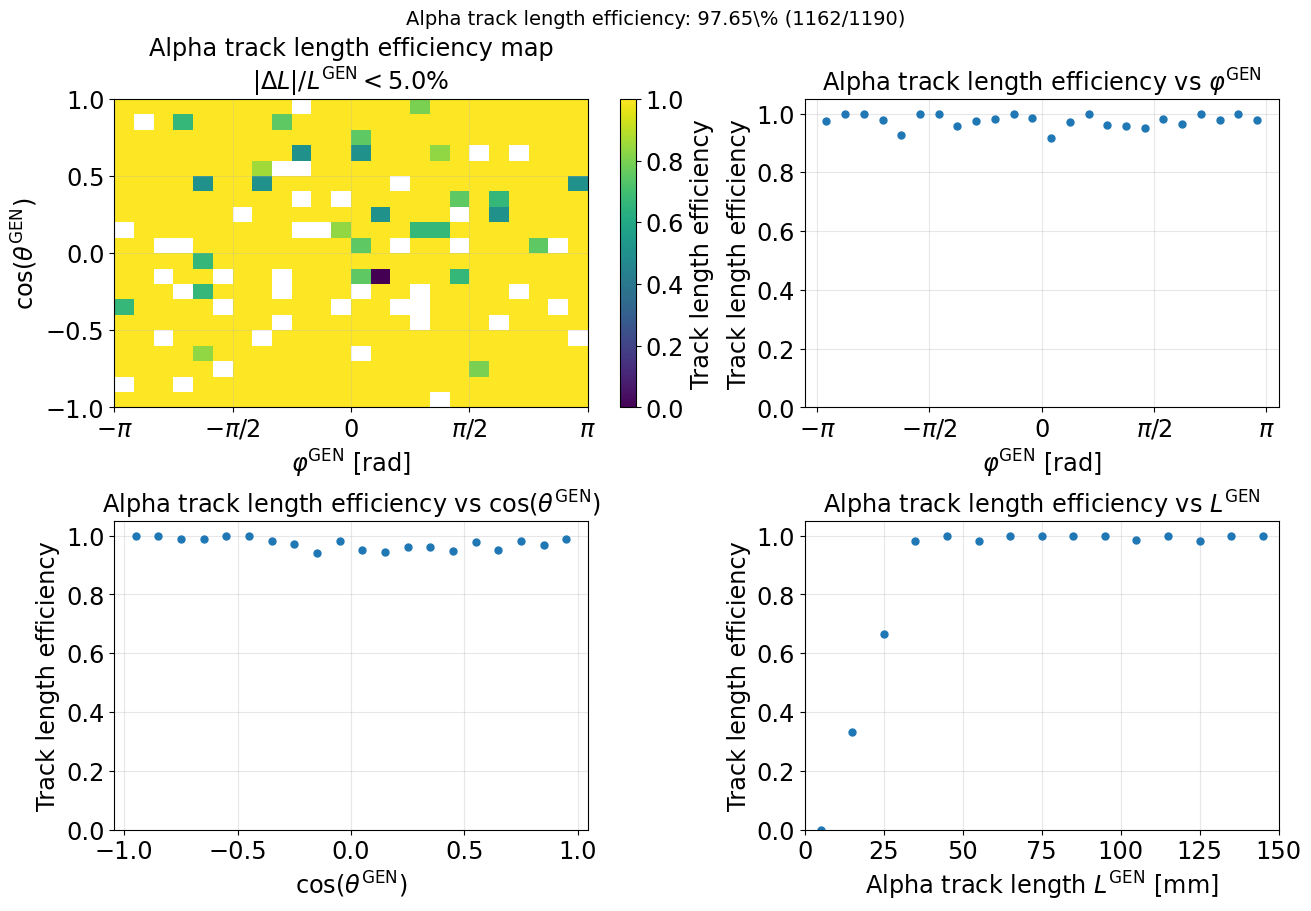

In [49]:
importlib.reload(plf)

fig, axes, df_eff, summary_carbon = plf.plotTrackLengthEffMaps(
    df,
    partName="Alpha",
    tolerance=0.05
)

Particle: Carbon
Angular tolerance: 3.0 deg
Good angular reconstructions: 392
All tracks in denominator: 1190
Mean angular efficiency: 0.3294 = 32.94%


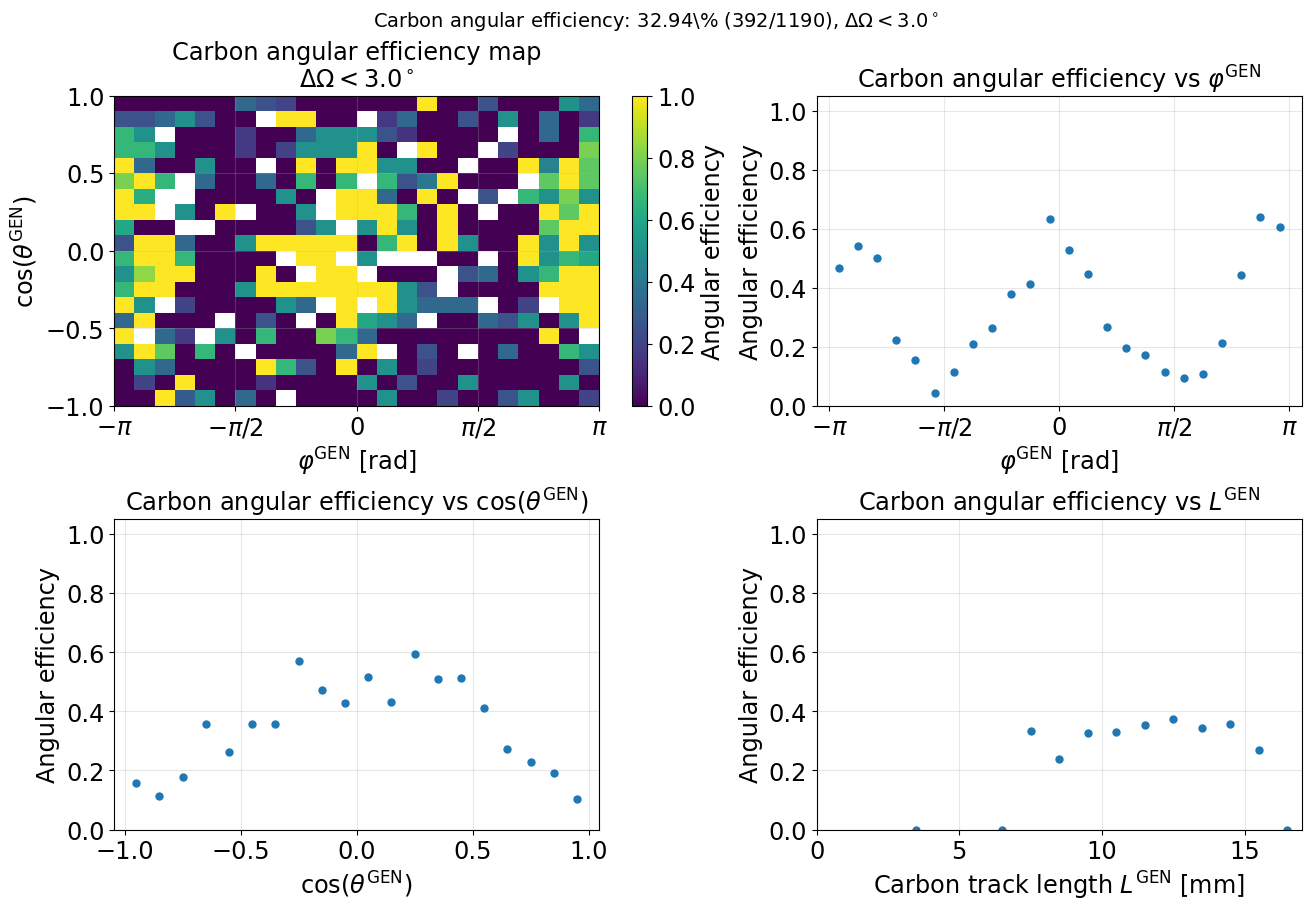

In [50]:
importlib.reload(plf)

fig, axes, df_ang_alpha, summary_alpha = plf.plotAngularEffMaps(
    df,
    partName="Carbon",
    angle_tolerance_deg=3.0
)

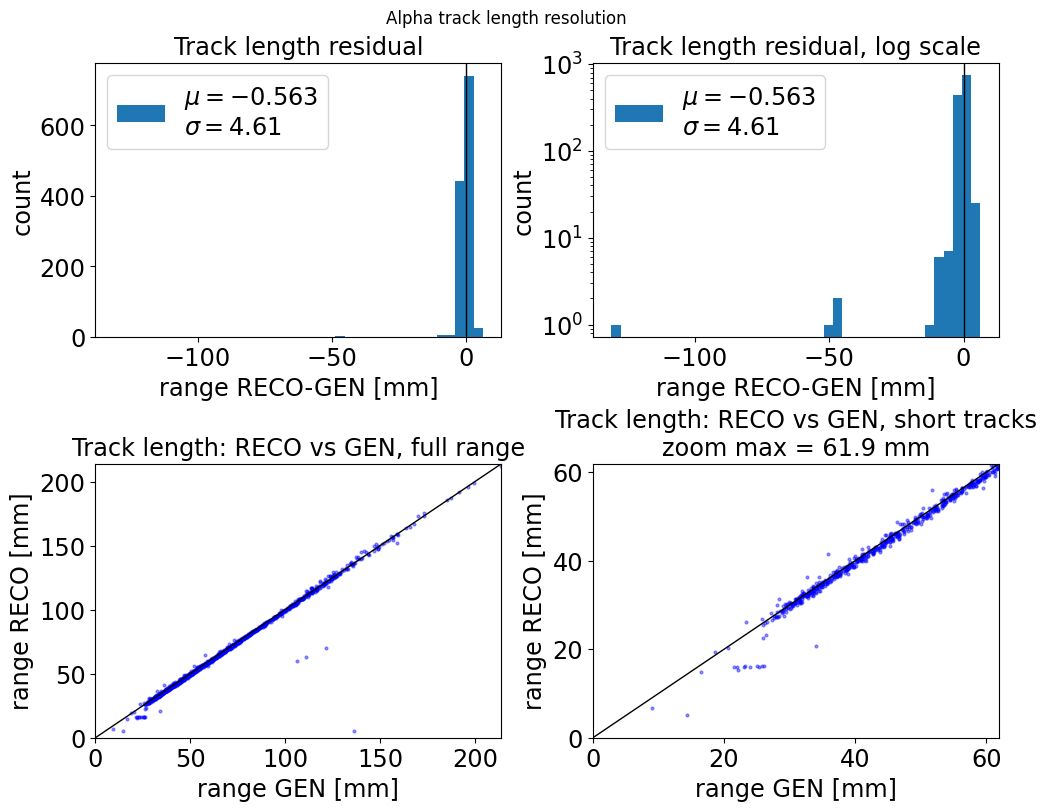

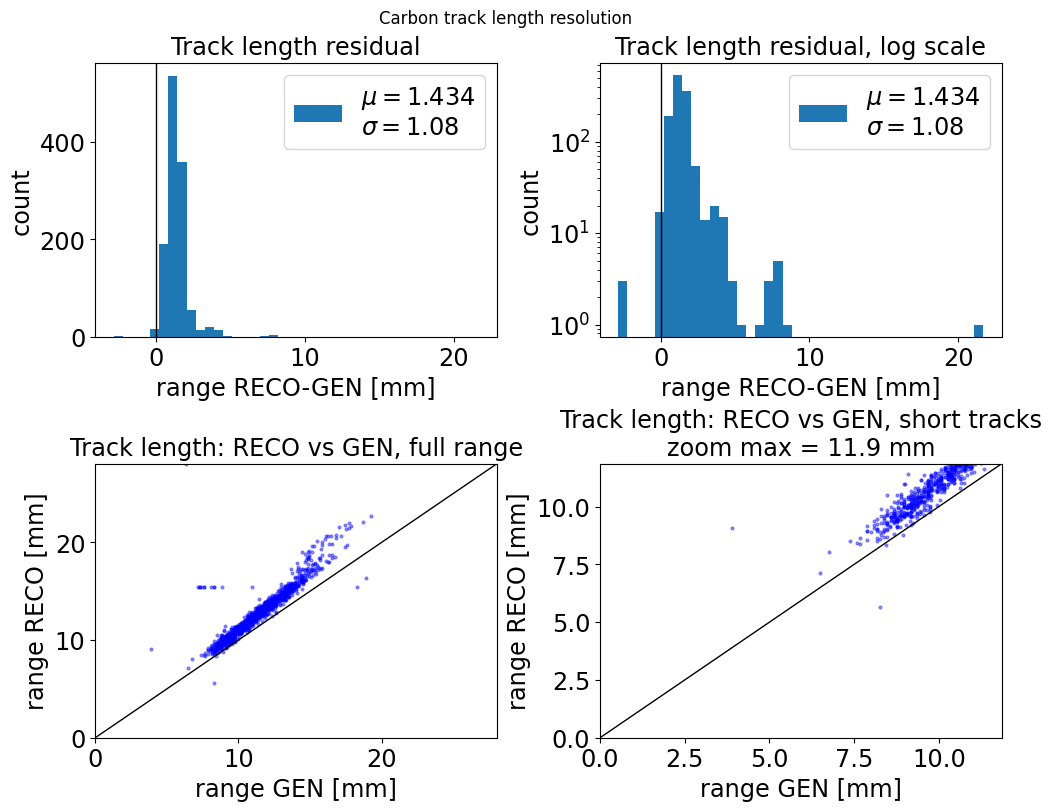

In [51]:
plf.plotLengthPull(df, partName="Alpha")
plf.plotLengthPull(df, partName="Carbon")

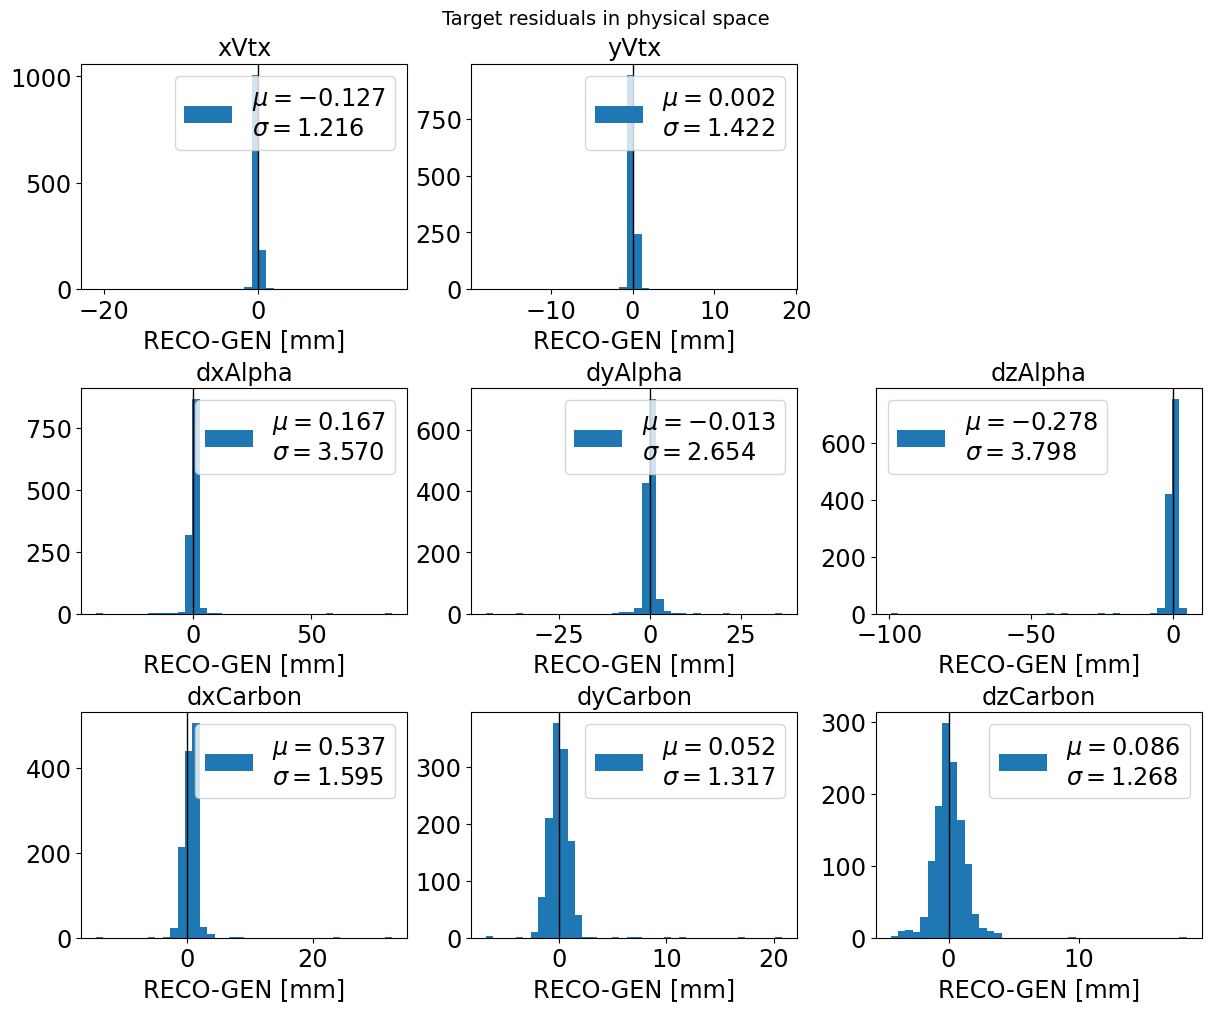

In [52]:
plf.plotTargetResiduals(df, normalized=False)

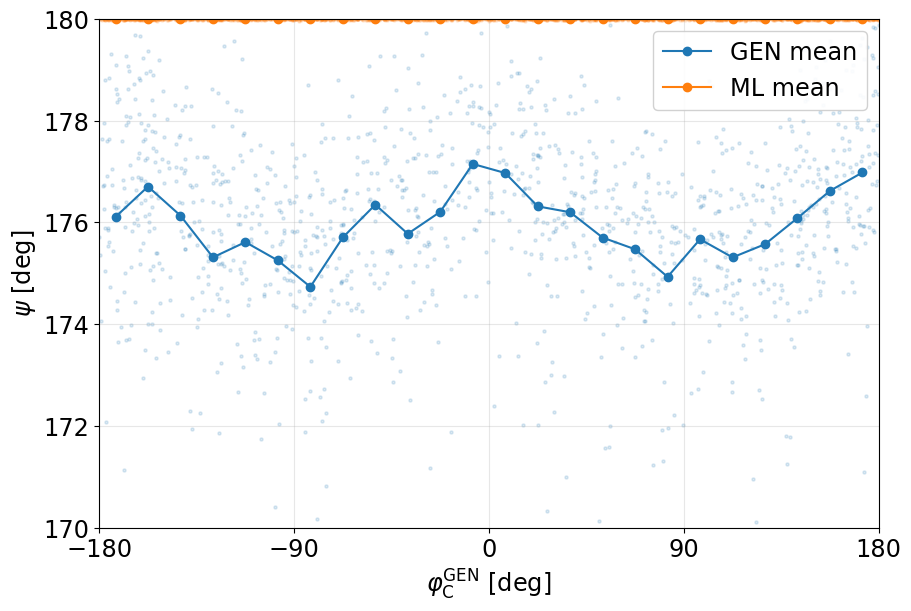

In [53]:
fig, ax, opening_vs_phi_deg = plf.plotOpeningAngleVsCarbonPhiDeg(
    df,
    phi_bins=24,
    show_scatter=True,
    ylim=(170, 180)
)